In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [2]:
!pip install xgboost imbalanced-learn

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [4]:
import pandas as pd

df = pd.read_csv(path + "/creditcard.csv")

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:


print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print(df["Class"].value_counts())

print("\nFraud percentage:",
      round(df["Class"].mean() * 100, 2), "%")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.17 %


In [7]:
# Features and target
X = df.drop(columns=["Class"])
y = df["Class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (284807, 30)
Target: (284807,)


In [8]:
# Train / validation split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [9]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [10]:
# XGBoost model
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_smote, y_train_smote)

print("Model trained successfully!")

Model trained successfully!


In [11]:
# Prediction probabilities
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9800336355701538


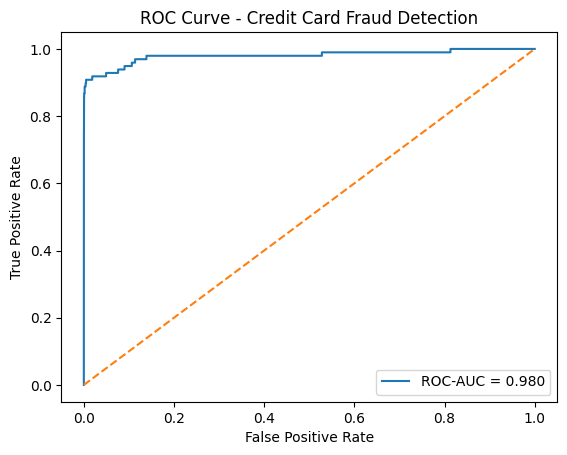

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.show()

In [13]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred
    ).ravel()

    recall = tp / (tp + fn)

    print(
        "Threshold:", threshold,
        "| Recall:", round(recall, 3),
        "| FP:", fp,
        "| FN:", fn
    )

Threshold: 0.3 | Recall: 0.908 | FP: 566 | FN: 9
Threshold: 0.4 | Recall: 0.908 | FP: 370 | FN: 9
Threshold: 0.5 | Recall: 0.898 | FP: 238 | FN: 10
Threshold: 0.6 | Recall: 0.888 | FP: 169 | FN: 11
Threshold: 0.7 | Recall: 0.888 | FP: 111 | FN: 11


In [14]:
threshold = 0.4

y_pred = (y_prob >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test, y_pred
).ravel()

print("Selected Threshold:", threshold)
print("True Positive :", tp)
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)

Selected Threshold: 0.4
True Positive : 89
True Negative : 56494
False Positive: 370
False Negative: 9


In [15]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

V14    0.521586
V10    0.092225
V17    0.044508
V4     0.040476
V12    0.033954
V8     0.021930
V5     0.021777
V3     0.020421
V13    0.018119
V1     0.015672
dtype: float32


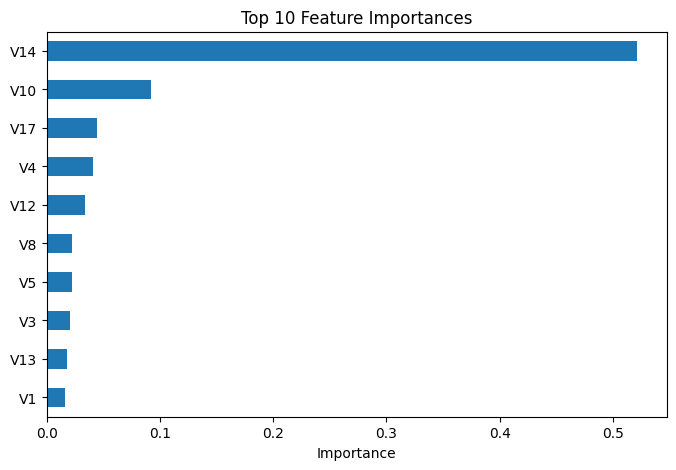

In [16]:
importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

## Conclusion

XGBoost was used to detect fraudulent credit card transactions.

The dataset is highly imbalanced because genuine transactions are much more
common than fraudulent transactions.

SMOTE was applied only to the training data to increase the representation
of the minority fraud class.

ROC-AUC was used to evaluate the model's ability to distinguish fraudulent
transactions from genuine transactions.

Different decision thresholds were tested because a threshold of 0.5 is not
always optimal for fraud detection.

False negatives are particularly important because they represent fraudulent
transactions that the model failed to detect.

Feature importance scores were used to identify the features that had the
greatest influence on the XGBoost model.